In [18]:
!pip install xgboost


Defaulting to user installation because normal site-packages is not writeable


In [19]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [20]:
# ============================================================
# BLOCK 1 — Install & Import Libraries
# ============================================================
!pip install -q scikit-learn xgboost joblib seaborn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from xgboost               import XGBClassifier
from sklearn.metrics       import (confusion_matrix,
                                   classification_report,
                                   roc_auc_score,
                                   roc_curve,
                                   recall_score,
                                   precision_score,
                                   f1_score,
                                   accuracy_score)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [21]:
# ============================================================
# BLOCK 2 — Load Processed Datasets
# ============================================================

train_df = pd.read_csv('data/processed_train.csv')
test_df  = pd.read_csv('data/processed_test.csv')

print("=" * 60)
print("PROCESSED DATASETS LOADED")
print("=" * 60)
print(f"  Train shape : {train_df.shape}")
print(f"  Test  shape : {test_df.shape}")
print(f"\n  Train — Normal: {(train_df['is_fraud']==0).sum():,}"
      f"  | Fraud: {train_df['is_fraud'].sum():,}")
print(f"  Test  — Normal: {(test_df['is_fraud']==0).sum():,}"
      f"  | Fraud: {test_df['is_fraud'].sum():,}")
print("=" * 60)
print("\n✅ Datasets loaded successfully!")

PROCESSED DATASETS LOADED
  Train shape : (1418085, 20)
  Test  shape : (555719, 20)

  Train — Normal: 1,289,169  | Fraud: 128,916
  Test  — Normal: 553,574  | Fraud: 2,145

✅ Datasets loaded successfully!


In [22]:
# ============================================================
# BLOCK 3 — Separate Features and Target
# ============================================================

X_train = train_df.drop(columns=['is_fraud'])
y_train = train_df['is_fraud']

X_test  = test_df.drop(columns=['is_fraud'])
y_test  = test_df['is_fraud']

print("=" * 60)
print("FEATURES & TARGET SEPARATED")
print("=" * 60)
print(f"  X_train : {X_train.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_test  : {y_test.shape}")
print(f"\n  Features ({len(X_train.columns)}):")
for col in X_train.columns:
    print(f"    → {col}")
print("=" * 60)
print("\n✅ Features and target separated!")

FEATURES & TARGET SEPARATED
  X_train : (1418085, 19)
  y_train : (1418085,)
  X_test  : (555719, 19)
  y_test  : (555719,)

  Features (19):
    → merchant
    → category
    → amt
    → gender
    → city
    → state
    → zip
    → lat
    → long
    → city_pop
    → job
    → merch_lat
    → merch_long
    → hour
    → day
    → month
    → day_of_year
    → age
    → distance

✅ Features and target separated!


In [23]:
# ============================================================
# BLOCK 4 — Train Logistic Regression
# ============================================================

print("⏳ Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter     = 1000,
    random_state = 42,
    class_weight = 'balanced',
    solver       = 'lbfgs',
    n_jobs       = -1
)

lr_model.fit(X_train, y_train)

print("=" * 60)
print("LOGISTIC REGRESSION — TRAINING COMPLETE ✅")
print("=" * 60)
print(f"  Solver       : lbfgs")
print(f"  Max Iter     : 1000")
print(f"  Class Weight : balanced")
print("=" * 60)
print("\n✅ Logistic Regression trained successfully!")

⏳ Training Logistic Regression...
LOGISTIC REGRESSION — TRAINING COMPLETE ✅
  Solver       : lbfgs
  Max Iter     : 1000
  Class Weight : balanced

✅ Logistic Regression trained successfully!


In [24]:
# ============================================================
# BLOCK 5 — Predict Using Logistic Regression
# ============================================================

lr_pred      = lr_model.predict(X_test)
lr_pred_prob = lr_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("LOGISTIC REGRESSION — PREDICTIONS")
print("=" * 60)
print(f"  Total Predictions  : {len(lr_pred):,}")
print(f"  Predicted Fraud    : {lr_pred.sum():,}")
print(f"  Predicted Normal   : {(lr_pred==0).sum():,}")
print(f"  Actual Fraud       : {y_test.sum():,}")
print("=" * 60)
print("\n✅ Predictions generated!")

LOGISTIC REGRESSION — PREDICTIONS
  Total Predictions  : 555,719
  Predicted Fraud    : 91,437
  Predicted Normal   : 464,282
  Actual Fraud       : 2,145

✅ Predictions generated!


   📊 LOGISTIC REGRESSION — EVALUATION
  Accuracy  : 83.59%
  Precision : 1.32%
  F1 Score  : 2.58%
  ROC-AUC   : 71.97%

  🔥 RECALL : 56.27%  ← MOST IMPORTANT
     Frauds Caught  : 1,207  out of  2,145
     Frauds Missed  : 938  ← want this LOW


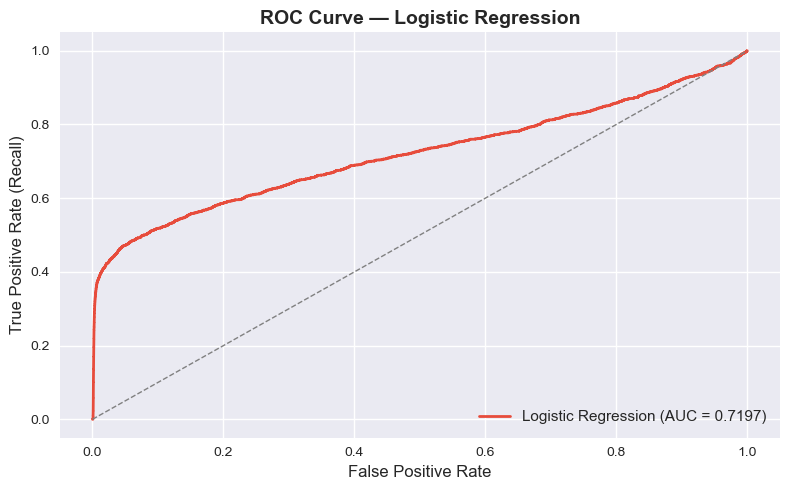

In [25]:
# ============================================================
# BLOCK 6 — Evaluate Logistic Regression
# ============================================================

lr_accuracy  = accuracy_score(y_test,  lr_pred)
lr_precision = precision_score(y_test, lr_pred, zero_division=0)
lr_recall    = recall_score(y_test,    lr_pred)
lr_f1        = f1_score(y_test,        lr_pred)
lr_roc_auc   = roc_auc_score(y_test,   lr_pred_prob)

print("=" * 60)
print("   📊 LOGISTIC REGRESSION — EVALUATION")
print("=" * 60)
print(f"  Accuracy  : {lr_accuracy  * 100:.2f}%")
print(f"  Precision : {lr_precision * 100:.2f}%")
print(f"  F1 Score  : {lr_f1        * 100:.2f}%")
print(f"  ROC-AUC   : {lr_roc_auc   * 100:.2f}%")
print("=" * 60)
print(f"\n  🔥 RECALL : {lr_recall * 100:.2f}%  ← MOST IMPORTANT")
print(f"     Frauds Caught  : "
      f"{int(lr_pred[y_test==1].sum()):,}"
      f"  out of  {int(y_test.sum()):,}")
print(f"     Frauds Missed  : "
      f"{int(y_test.sum()) - int(lr_pred[y_test==1].sum()):,}"
      f"  ← want this LOW")
print("=" * 60)

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_prob)
plt.figure(figsize=(8, 5))
plt.plot(fpr_lr, tpr_lr, color='#e74c3c', lw=2,
         label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — Logistic Regression',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

CONFUSION MATRIX — Logistic Regression
  True  Negative (TN) : 463,344  ← Normal correctly identified
  False Positive (FP) : 90,230   ← Normal flagged as Fraud
  False Negative (FN) : 938   ← Fraud MISSED        ❌
  True  Positive (TP) : 1,207   ← Fraud correctly caught ✅


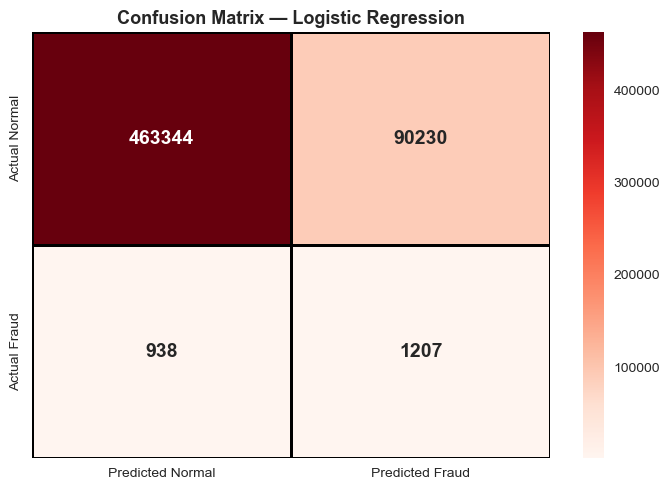

In [26]:
# ============================================================
# BLOCK 7 — Confusion Matrix — Logistic Regression
# ============================================================

cm_lr          = confusion_matrix(y_test, lr_pred)
tn, fp, fn, tp = cm_lr.ravel()

print("=" * 60)
print("CONFUSION MATRIX — Logistic Regression")
print("=" * 60)
print(f"  True  Negative (TN) : {tn:,}  ← Normal correctly identified")
print(f"  False Positive (FP) : {fp:,}   ← Normal flagged as Fraud")
print(f"  False Negative (FN) : {fn:,}   ← Fraud MISSED        ❌")
print(f"  True  Positive (TP) : {tp:,}   ← Fraud correctly caught ✅")
print("=" * 60)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr,
            annot=True, fmt='d',
            cmap='Reds',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal',    'Actual Fraud'],
            linewidths=1, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix — Logistic Regression',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# BLOCK 8 — Classification Report — Logistic Regression
# ============================================================

print("=" * 60)
print("CLASSIFICATION REPORT — Logistic Regression")
print("=" * 60)
print(classification_report(
    y_test, lr_pred,
    target_names=['Normal (0)', 'Fraud (1)'],
    zero_division=0))
print("=" * 60)
print(f"\n  🔥 Fraud Recall : {lr_recall*100:.2f}%")
print(f"     = We caught {lr_recall*100:.2f}% of all fraud cases")
print("=" * 60)

CLASSIFICATION REPORT — Logistic Regression
              precision    recall  f1-score   support

  Normal (0)       1.00      0.84      0.91    553574
   Fraud (1)       0.01      0.56      0.03      2145

    accuracy                           0.84    555719
   macro avg       0.51      0.70      0.47    555719
weighted avg       0.99      0.84      0.91    555719


  🔥 Fraud Recall : 56.27%
     = We caught 56.27% of all fraud cases


In [28]:
# ============================================================
# BLOCK 9 — Train Random Forest
# ============================================================

print("⏳ Training Random Forest...")
print("   (This may take 2–4 minutes)")

rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 20,
    random_state = 42,
    class_weight = 'balanced',
    n_jobs       = -1
)

rf_model.fit(X_train, y_train)

print("=" * 60)
print("RANDOM FOREST — TRAINING COMPLETE ✅")
print("=" * 60)
print(f"  Trees (n_estimators) : 100")
print(f"  Max Depth            : 20")
print(f"  Class Weight         : balanced")
print(f"  CPU Cores            : all (-1)")
print("=" * 60)
print("\n✅ Random Forest trained successfully!")

⏳ Training Random Forest...
   (This may take 2–4 minutes)
RANDOM FOREST — TRAINING COMPLETE ✅
  Trees (n_estimators) : 100
  Max Depth            : 20
  Class Weight         : balanced
  CPU Cores            : all (-1)

✅ Random Forest trained successfully!


In [29]:
# ============================================================
# BLOCK 10 — Predict Using Random Forest
# ============================================================

rf_pred      = rf_model.predict(X_test)
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("RANDOM FOREST — PREDICTIONS")
print("=" * 60)
print(f"  Total Predictions  : {len(rf_pred):,}")
print(f"  Predicted Fraud    : {rf_pred.sum():,}")
print(f"  Predicted Normal   : {(rf_pred==0).sum():,}")
print(f"  Actual Fraud       : {y_test.sum():,}")
print("=" * 60)
print("\n✅ Predictions generated!")

RANDOM FOREST — PREDICTIONS
  Total Predictions  : 555,719
  Predicted Fraud    : 4,776
  Predicted Normal   : 550,943
  Actual Fraud       : 2,145

✅ Predictions generated!


   📊 RANDOM FOREST — EVALUATION
  Accuracy  : 99.33%
  Precision : 33.50%
  F1 Score  : 46.24%
  ROC-AUC   : 96.24%

  🔥 RECALL : 74.59%  ← MOST IMPORTANT
     Frauds Caught  : 1,600  out of  2,145
     Frauds Missed  : 545  ← want this LOW


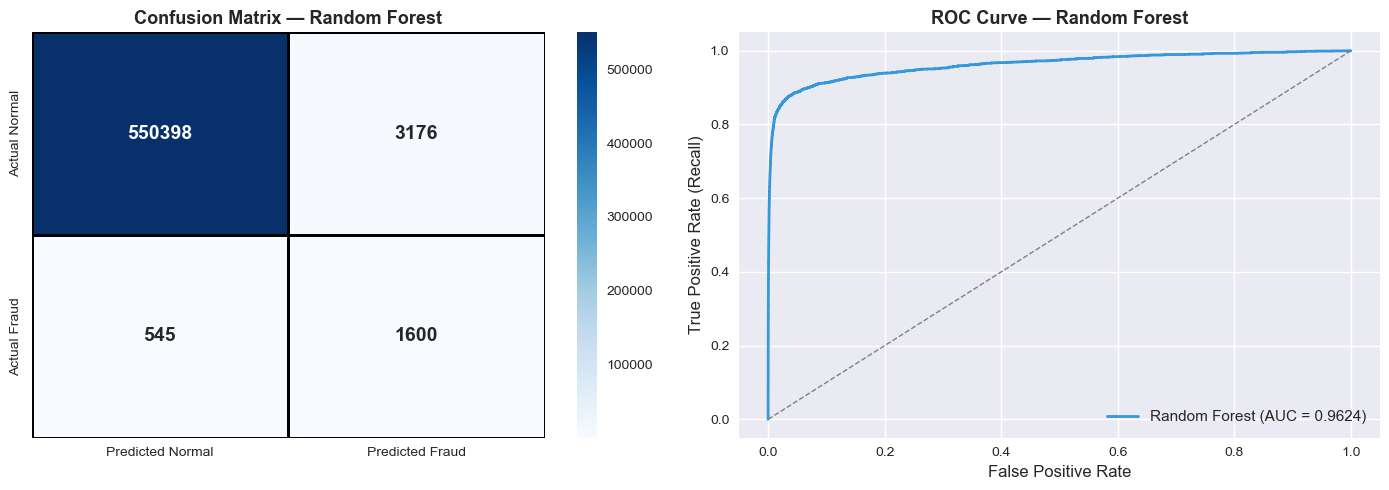

CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      1.00    553574
   Fraud (1)       0.34      0.75      0.46      2145

    accuracy                           0.99    555719
   macro avg       0.67      0.87      0.73    555719
weighted avg       1.00      0.99      0.99    555719



In [30]:
# ============================================================
# BLOCK 11 — Evaluate Random Forest
# ============================================================

rf_accuracy  = accuracy_score(y_test,  rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall    = recall_score(y_test,    rf_pred)
rf_f1        = f1_score(y_test,        rf_pred)
rf_roc_auc   = roc_auc_score(y_test,   rf_pred_prob)

print("=" * 60)
print("   📊 RANDOM FOREST — EVALUATION")
print("=" * 60)
print(f"  Accuracy  : {rf_accuracy  * 100:.2f}%")
print(f"  Precision : {rf_precision * 100:.2f}%")
print(f"  F1 Score  : {rf_f1        * 100:.2f}%")
print(f"  ROC-AUC   : {rf_roc_auc   * 100:.2f}%")
print("=" * 60)
print(f"\n  🔥 RECALL : {rf_recall * 100:.2f}%  ← MOST IMPORTANT")
print(f"     Frauds Caught  : "
      f"{int(rf_pred[y_test==1].sum()):,}"
      f"  out of  {int(y_test.sum()):,}")
print(f"     Frauds Missed  : "
      f"{int(y_test.sum()) - int(rf_pred[y_test==1].sum()):,}"
      f"  ← want this LOW")
print("=" * 60)

# Confusion matrix + ROC side by side
cm_rf          = confusion_matrix(y_test, rf_pred)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf,
            annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal',    'Actual Fraud'],
            linewidths=1, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=axes[0])
axes[0].set_title('Confusion Matrix — Random Forest',
                  fontsize=13, fontweight='bold')

axes[1].plot(fpr_rf, tpr_rf, color='#3498db', lw=2,
             label=f'Random Forest (AUC = {rf_roc_auc:.4f})')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('ROC Curve — Random Forest',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

print("=" * 60)
print("CLASSIFICATION REPORT — Random Forest")
print("=" * 60)
print(classification_report(
    y_test, rf_pred,
    target_names=['Normal (0)', 'Fraud (1)'],
    zero_division=0))

In [31]:
# ============================================================
# BLOCK 12 — Train XGBoost
# ============================================================

print("⏳ Training XGBoost...")
print("   (This may take 2–3 minutes)")

# Calculate scale_pos_weight for imbalance handling
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb_model = XGBClassifier(
    n_estimators      = 100,
    max_depth         = 6,
    learning_rate     = 0.1,
    scale_pos_weight  = scale,
    random_state      = 42,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    n_jobs            = -1
)

xgb_model.fit(X_train, y_train)

print("=" * 60)
print("XGBOOST — TRAINING COMPLETE ✅")
print("=" * 60)
print(f"  n_estimators     : 100")
print(f"  Max Depth        : 6")
print(f"  Learning Rate    : 0.1")
print(f"  Scale Pos Weight : {scale:.2f}")
print("=" * 60)
print("\n✅ XGBoost trained successfully!")

⏳ Training XGBoost...
   (This may take 2–3 minutes)
XGBOOST — TRAINING COMPLETE ✅
  n_estimators     : 100
  Max Depth        : 6
  Learning Rate    : 0.1
  Scale Pos Weight : 10.00

✅ XGBoost trained successfully!


   📊 XGBOOST — EVALUATION
  Accuracy  : 97.97%
  Precision : 14.45%
  F1 Score  : 24.76%
  ROC-AUC   : 97.95%

  🔥 RECALL : 86.48%  ← MOST IMPORTANT
     Frauds Caught : 1,855  out of  2,145
     Frauds Missed : 290


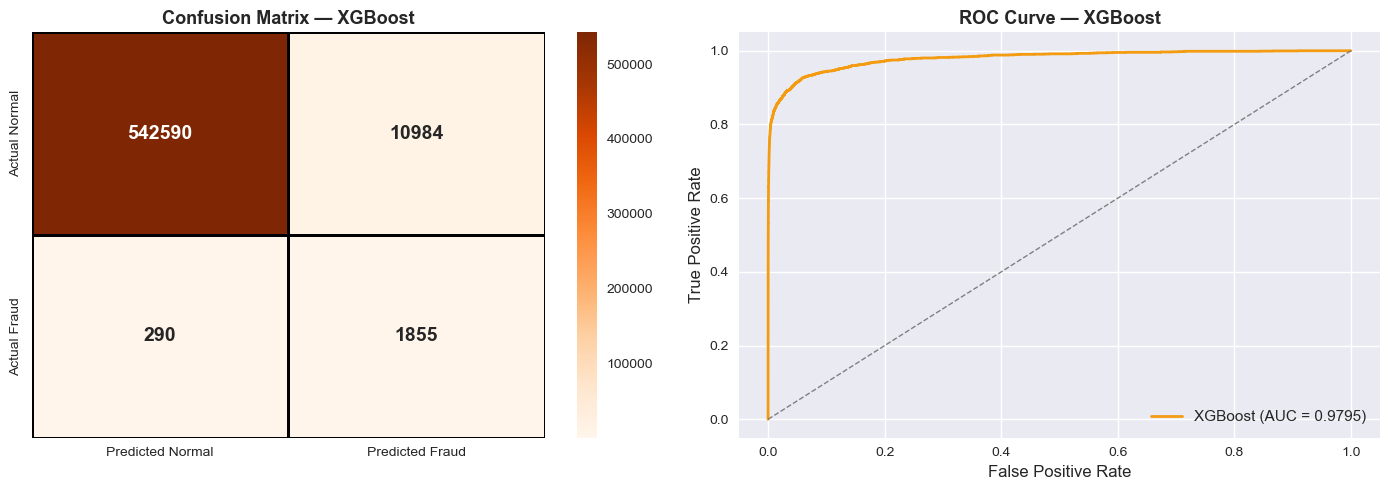

CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

  Normal (0)       1.00      0.98      0.99    553574
   Fraud (1)       0.14      0.86      0.25      2145

    accuracy                           0.98    555719
   macro avg       0.57      0.92      0.62    555719
weighted avg       1.00      0.98      0.99    555719



In [32]:
# ============================================================
# BLOCK 13 — Predict & Evaluate XGBoost
# ============================================================

xgb_pred      = xgb_model.predict(X_test)
xgb_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy  = accuracy_score(y_test,  xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall    = recall_score(y_test,    xgb_pred)
xgb_f1        = f1_score(y_test,        xgb_pred)
xgb_roc_auc   = roc_auc_score(y_test,   xgb_pred_prob)

print("=" * 60)
print("   📊 XGBOOST — EVALUATION")
print("=" * 60)
print(f"  Accuracy  : {xgb_accuracy  * 100:.2f}%")
print(f"  Precision : {xgb_precision * 100:.2f}%")
print(f"  F1 Score  : {xgb_f1        * 100:.2f}%")
print(f"  ROC-AUC   : {xgb_roc_auc   * 100:.2f}%")
print("=" * 60)
print(f"\n  🔥 RECALL : {xgb_recall * 100:.2f}%  ← MOST IMPORTANT")
print(f"     Frauds Caught : "
      f"{int(xgb_pred[y_test==1].sum()):,}"
      f"  out of  {int(y_test.sum()):,}")
print(f"     Frauds Missed : "
      f"{int(y_test.sum()) - int(xgb_pred[y_test==1].sum()):,}")
print("=" * 60)

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_xgb,
            annot=True, fmt='d',
            cmap='Oranges',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal',    'Actual Fraud'],
            linewidths=1, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=axes[0])
axes[0].set_title('Confusion Matrix — XGBoost',
                  fontsize=13, fontweight='bold')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_prob)
axes[1].plot(fpr_xgb, tpr_xgb, color='#f39c12', lw=2,
             label=f'XGBoost (AUC = {xgb_roc_auc:.4f})')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve — XGBoost',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

print("=" * 60)
print("CLASSIFICATION REPORT — XGBoost")
print("=" * 60)
print(classification_report(
    y_test, xgb_pred,
    target_names=['Normal (0)', 'Fraud (1)'],
    zero_division=0))

          📊 ALL MODELS COMPARISON TABLE
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     83.59       1.32   56.27      2.58    71.97
      Random Forest     99.33      33.50   74.59     46.24    96.24
            XGBoost     97.97      14.45   86.48     24.76    97.95

  🔥 RECALL SCORES (Most Important):
     Logistic Regression : 56.27%
     Random Forest       : 74.59%
     XGBoost             : 86.48%


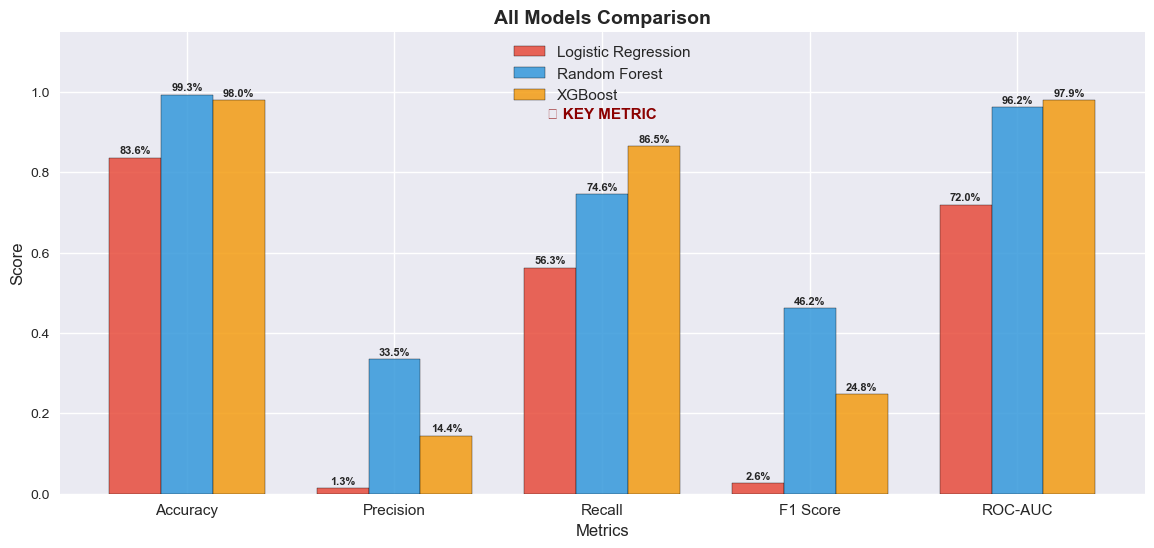

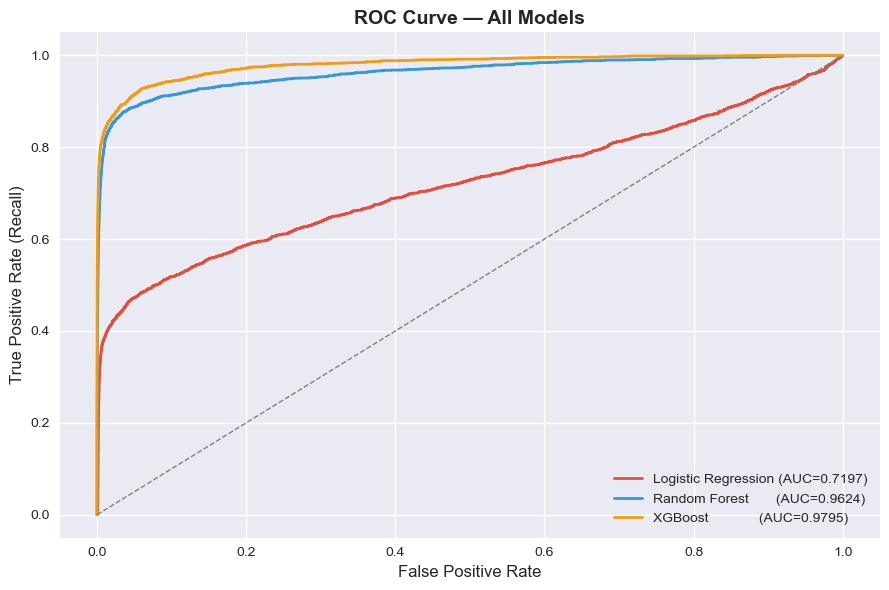

In [33]:
# ============================================================
# BLOCK 14 — Compare All 3 Models
# ============================================================

results = pd.DataFrame({
    'Model'    : ['Logistic Regression',
                  'Random Forest',
                  'XGBoost'],
    'Accuracy' : [round(lr_accuracy  * 100, 2),
                  round(rf_accuracy  * 100, 2),
                  round(xgb_accuracy * 100, 2)],
    'Precision': [round(lr_precision  * 100, 2),
                  round(rf_precision  * 100, 2),
                  round(xgb_precision * 100, 2)],
    'Recall'   : [round(lr_recall  * 100, 2),
                  round(rf_recall  * 100, 2),
                  round(xgb_recall * 100, 2)],
    'F1 Score' : [round(lr_f1  * 100, 2),
                  round(rf_f1  * 100, 2),
                  round(xgb_f1 * 100, 2)],
    'ROC-AUC'  : [round(lr_roc_auc  * 100, 2),
                  round(rf_roc_auc  * 100, 2),
                  round(xgb_roc_auc * 100, 2)],
})

print("=" * 65)
print("          📊 ALL MODELS COMPARISON TABLE")
print("=" * 65)
print(results.to_string(index=False))
print("=" * 65)
print(f"\n  🔥 RECALL SCORES (Most Important):")
print(f"     Logistic Regression : {lr_recall  * 100:.2f}%")
print(f"     Random Forest       : {rf_recall  * 100:.2f}%")
print(f"     XGBoost             : {xgb_recall * 100:.2f}%")

# Bar chart comparison
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
lr_vals  = [lr_accuracy,  lr_precision,  lr_recall,  lr_f1,  lr_roc_auc]
rf_vals  = [rf_accuracy,  rf_precision,  rf_recall,  rf_f1,  rf_roc_auc]
xgb_vals = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_roc_auc]

x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width, lr_vals,  width,
            label='Logistic Regression',
            color='#e74c3c', edgecolor='black', alpha=0.85)
b2 = ax.bar(x,          rf_vals,  width,
            label='Random Forest',
            color='#3498db', edgecolor='black', alpha=0.85)
b3 = ax.bar(x + width,  xgb_vals, width,
            label='XGBoost',
            color='#f39c12', edgecolor='black', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height()*100:.1f}%',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models Comparison',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.annotate('🔥 KEY METRIC',
            xy=(x[2], max(lr_recall, rf_recall,
                          xgb_recall) + 0.07),
            ha='center', fontsize=11,
            color='darkred', fontweight='bold')

# ROC Curve comparison
fig2, ax2 = plt.subplots(figsize=(9, 6))
ax2.plot(fpr_lr,  tpr_lr,  color='#e74c3c', lw=2,
         label=f'Logistic Regression (AUC={lr_roc_auc:.4f})')
ax2.plot(fpr_rf,  tpr_rf,  color='#3498db', lw=2,
         label=f'Random Forest       (AUC={rf_roc_auc:.4f})')
ax2.plot(fpr_xgb, tpr_xgb, color='#f39c12', lw=2,
         label=f'XGBoost             (AUC={xgb_roc_auc:.4f})')
ax2.plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax2.set_title('ROC Curve — All Models',
              fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# BLOCK 15 — Save Best Model
# ============================================================

os.makedirs('models', exist_ok=True)

# Best model = highest Recall
recall_scores = {
    'Logistic Regression' : (lr_recall,  lr_model),
    'Random Forest'       : (rf_recall,  rf_model),
    'XGBoost'             : (xgb_recall, xgb_model),
}

best_name   = max(recall_scores, key=lambda k: recall_scores[k][0])
best_recall = recall_scores[best_name][0]
best_model  = recall_scores[best_name][1]

model_path  = 'models/fraud_model.pkl'
joblib.dump(best_model, model_path)

print("=" * 60)
print("   💾 BEST MODEL SAVED")
print("=" * 60)
print(f"  🏆 Best Model   : {best_name}")
print(f"  🔥 Recall Score : {best_recall * 100:.2f}%")
print(f"  📁 Saved at     : {model_path}")
print(f"  📦 File size    : "
      f"{os.path.getsize(model_path)/1024:.2f} KB")
print("=" * 60)
print("\n✅ Best model saved as fraud_model.pkl!")

   💾 BEST MODEL SAVED
  🏆 Best Model   : XGBoost
  🔥 Recall Score : 86.48%
  📁 Saved at     : models/fraud_model.pkl
  📦 File size    : 443.46 KB

✅ Best model saved as fraud_model.pkl!
